# Single Band Photometry and Matching

## 1. Initial Setting

In [15]:
from astropy.table import Table
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales
import astropy.units as u
from astropy.io import fits
from astropy.stats import sigma_clipped_stats
from astropy.visualization import (
    ImageNormalize,
    ZScaleInterval,
    PercentileInterval,
    AsinhStretch,
    LogStretch,
    SqrtStretch
)

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import glob
from pathlib import Path
import subprocess
from tqdm.auto import tqdm
import random

def get_image_path(cosmos, band, weight=False):
    image_folder = DATA_ROOT / f"COSMOS{cosmos}"

    suffix = "weight.fits" if weight else "com.fits"
    paths = list(image_folder.glob(f"*{band}*.{suffix}"))

    if len(paths) == 0:
        print(
            f"COSMOS {cosmos} - {band}: no matching {suffix} file."
        )
        return None

    if len(paths) > 1:
        raise RuntimeError(
            f"COSMOS {cosmos} - {band}: multiple matching {suffix} files."
        )

    return paths[0]

def get_catalog_path(cosmos, band):
    return PROJECT_ROOT / f'output/COSMOS{cosmos}/singlebandphot/cat_cosmos{cosmos}_{band}.fits'

def plot_ImageAndDetectedSources(image, cat, center_point=None, length=None, show_source_id=True, save_path=None):
    if center_point is not None and length is not None:
        half = length / 2
        xmin = max(0, int(center_point[0] - half))
        xmax = min(image.shape[1], int(center_point[0] + half))
        ymin = max(0, int(center_point[1] - half))
        ymax = min(image.shape[0], int(center_point[1] + half))

        cat_plot = cat[
            (xmin <= cat['pixel_centroid_x'])
            & (cat['pixel_centroid_x'] < xmax)
            & (ymin <= cat['pixel_centroid_y'])
            & (cat['pixel_centroid_y'] < ymax)
        ]

        image_plot = image[ymin:ymax, xmin:xmax]

    else:
        ymin, xmin = 0, 0
        ymax, xmax = image.shape

        cat_plot = cat
        image_plot = image

    norm = ImageNormalize(
        image_plot,
        interval=ZScaleInterval(),
        #stretch=
    )

    fig, ax = plt.subplots(figsize=(10, 10))

    ax.imshow(
        image_plot,
        cmap='gray',
        norm=norm,
        origin='lower',
        extent=[xmin, xmax, ymin, ymax]
    )

    radius_pix = 5.94
    # If there exists 'master_id" column, use it instead of source_id
    if 'master_id' in cat_plot.colnames:
        cat_plot['source_id'] = cat_plot['master_id']
    for x, y, source_id in zip(
        cat_plot['pixel_centroid_x'],
        cat_plot['pixel_centroid_y'],
        cat_plot['source_id']
    ):
        ax.add_patch(
            Circle(
                (x, y),
                radius=radius_pix,
                fill=False,
                edgecolor='red',
                linewidth=1
            )
        )

        if show_source_id and length is not None and length < 500:
            ax.text(
                x + radius_pix,
                y + radius_pix,
                str(source_id),
                color='yellow',
                fontsize=7,
                ha='left',
                va='bottom',
                bbox=dict(facecolor='black', alpha=0.5, edgecolor='none', pad=1),
            )

    # Draw crosshair at center_point
    if center_point is not None:
        ax.axhline(y=center_point[1], color='cyan', linestyle='--', linewidth=0.8, alpha=0.7)
        ax.axvline(x=center_point[0], color='cyan', linestyle='--', linewidth=0.8, alpha=0.7)

    ax.set_xlabel('X pixel')
    ax.set_ylabel('Y pixel')

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Saved image to {save_path}')
    else:
        plt.show()

# Image preparation
COSMOS = 1
PROJECT_ROOT = Path("..").resolve()
DATA_ROOT = PROJECT_ROOT/'COSMOS_data'
BANDS_7DT = [f"m{i}" for i in range(400, 900, 25)]
MASK_ROOT = DATA_ROOT / f"COSMOS{COSMOS}/COSMOS{COSMOS}_validmask.fits"

valid_mask = fits.open(MASK_ROOT)[0].data
valid_mask = valid_mask.astype(bool)

# Make available bands
available_band = []
image_paths = {}
weight_paths = {}
zero_points = {}

for band in BANDS_7DT : 
    band_path = get_image_path(COSMOS, band)
    weight_path = get_image_path(COSMOS, band, weight=True)
    if band_path is None : continue
    available_band.append(band)
    image_paths[band] = band_path
    weight_paths[band] = weight_path
    with fits.open(band_path) as hdul : 
        header = hdul[0].header
    zero_points[band] = float(header['ZP_3'])

print(f'{len(available_band)} bands are available.')

first_band = available_band[0]
with fits.open(image_paths[first_band]) as hdul : 
    data = hdul[0].data
    wcs = WCS(hdul[0].header)


# <============ Important settings ============>

PIXEL_SCALE = (proj_plane_pixel_scales(wcs)[0] * u.deg).to(u.arcsec)
APER_3ARCSEC_PIXEL = 3 * u.arcsec / PIXEL_SCALE
DETECTION_THRESHOLD = 3
DETECTION_MINIMUM_AREA = 3
THREAD_COUNT = 1


20 bands are available.


## 2. Single Band Photometry

In [5]:
for band in tqdm(available_band):
    image_path = image_paths[band]
    weight_path = weight_paths[band]

    pyconfig_path = PROJECT_ROOT / f"seppconfig/singlephot_cosmos{COSMOS}_{band}.py"
    config_path = PROJECT_ROOT / f"seppconfig/singlephot_cosmos{COSMOS}_{band}.config"
    pyconfig_path.parent.mkdir(parents=True, exist_ok=True)
    zero_point = zero_points[band]
    
    catalog_path = (
        PROJECT_ROOT
        / f"output/COSMOS{COSMOS}/singlebandphot"
        / f"cat_cosmos{COSMOS}_{band}.fits"
    )
    catalog_path.parent.mkdir(parents=True, exist_ok=True)

    pyconfig_code = f"""
from sourcextractor.config import *

image_group = load_fits_image(
    {str(image_path)!r},
    # weight={str(weight_path)!r},
    # weight_type='weight'
)

meas_group = MeasurementGroup(image_group)

aper = []

for img in meas_group:
    aper.extend(
        add_aperture_photometry(
            img,
            {APER_3ARCSEC_PIXEL}
        )
    )

add_output_column("aper3", aper)
"""


    config_code = f"""
detection-image={image_path}

detection-threshold={DETECTION_THRESHOLD}
detection-minimum-area={DETECTION_MINIMUM_AREA}
magnitude-zero-point={zero_point}

python-config-file={pyconfig_path}

output-properties=SourceIDs,PixelCentroid,WorldCentroid,AperturePhotometry,SNRRatio,ShapeParameters,FluxRadius
output-catalog-filename={catalog_path}

segmentation-use-filtering=false
thread-count={THREAD_COUNT}
"""
    pyconfig_path.write_text(pyconfig_code)
    config_path.write_text(config_code) 
    
    command = [
        'sourcextractor++', 
        '--config-file', 
        str(config_path)
    ]
    
    subprocess.run(command, check=True)

print('Single Band Catalog Process finished')

  0%|          | 0/20 [00:00<?, ?it/s]

2026-09-09T14:34:05KST FitsFile  INFO : Creating shared LRUFileManager with limit of 500 open files.
2026-09-09T14:34:06KST BackgroundModel  INFO : Background for image: Masked(BufferedImage(/Users/mac_seo/Research_local/7DTonCOSMOS/COSMOS_data/COSMOS1/calib_7DT_COSMOS_1_20240528_234348_m400_4320.com.fits)) with 0.0 weight image masked pixels; median: 1.11128 rms: 1.97927!
2026-09-09T14:34:07KST BackgroundModel  INFO : Background for image: Masked(BufferedImage(/Users/mac_seo/Research_local/7DTonCOSMOS/COSMOS_data/COSMOS1/calib_7DT_COSMOS_1_20240528_234348_m400_4320.com.fits)) with 0.0 weight image masked pixels; median: 1.11128 rms: 1.97927!
2026-09-09T14:34:07KST FlexibleModelFitting  INFO : Using engine levmar with the iterative implementation and 200 maximum number of iterations, window type: 1
2026-09-09T14:34:07KST SourceXtractor  INFO : Writing output following segmentation order
2026-09-09T14:34:07KST SourceXtractor  INFO : Processing frame 1 / 1 : calib_7DT_COSMOS_1_20240528_2

Single Band Catalog Process finished


2026-09-09T14:44:21KST SourceXtractor  INFO : 36936 sources detected in frame, 36936 total
2026-09-09T14:44:21KST Progress  INFO : Segmentation: 6800 / 6800 (100.00%)
2026-09-09T14:44:21KST Progress  INFO : Detected: 212843
2026-09-09T14:44:21KST Progress  INFO : Deblended: 36936
2026-09-09T14:44:21KST Progress  INFO : Measured: 36936 / 36936 (100.00%)
2026-09-09T14:44:21KST Progress  INFO : Elapsed: 00:00:38
2026-09-09T14:44:21KST SourceXtractor  INFO : total 36936 sources detected
2026-09-09T14:44:21KST Python::Interpreter  INFO : Python GIL acquired 19 times


Check the result

  0%|          | 0/20 [00:00<?, ?it/s]

m400: 1815 good sources


m425: 3452 good sources


m450: 2467 good sources


m475: 4163 good sources


m500: 4003 good sources


m525: 5347 good sources


m550: 2934 good sources


m575: 6002 good sources


KeyboardInterrupt: 

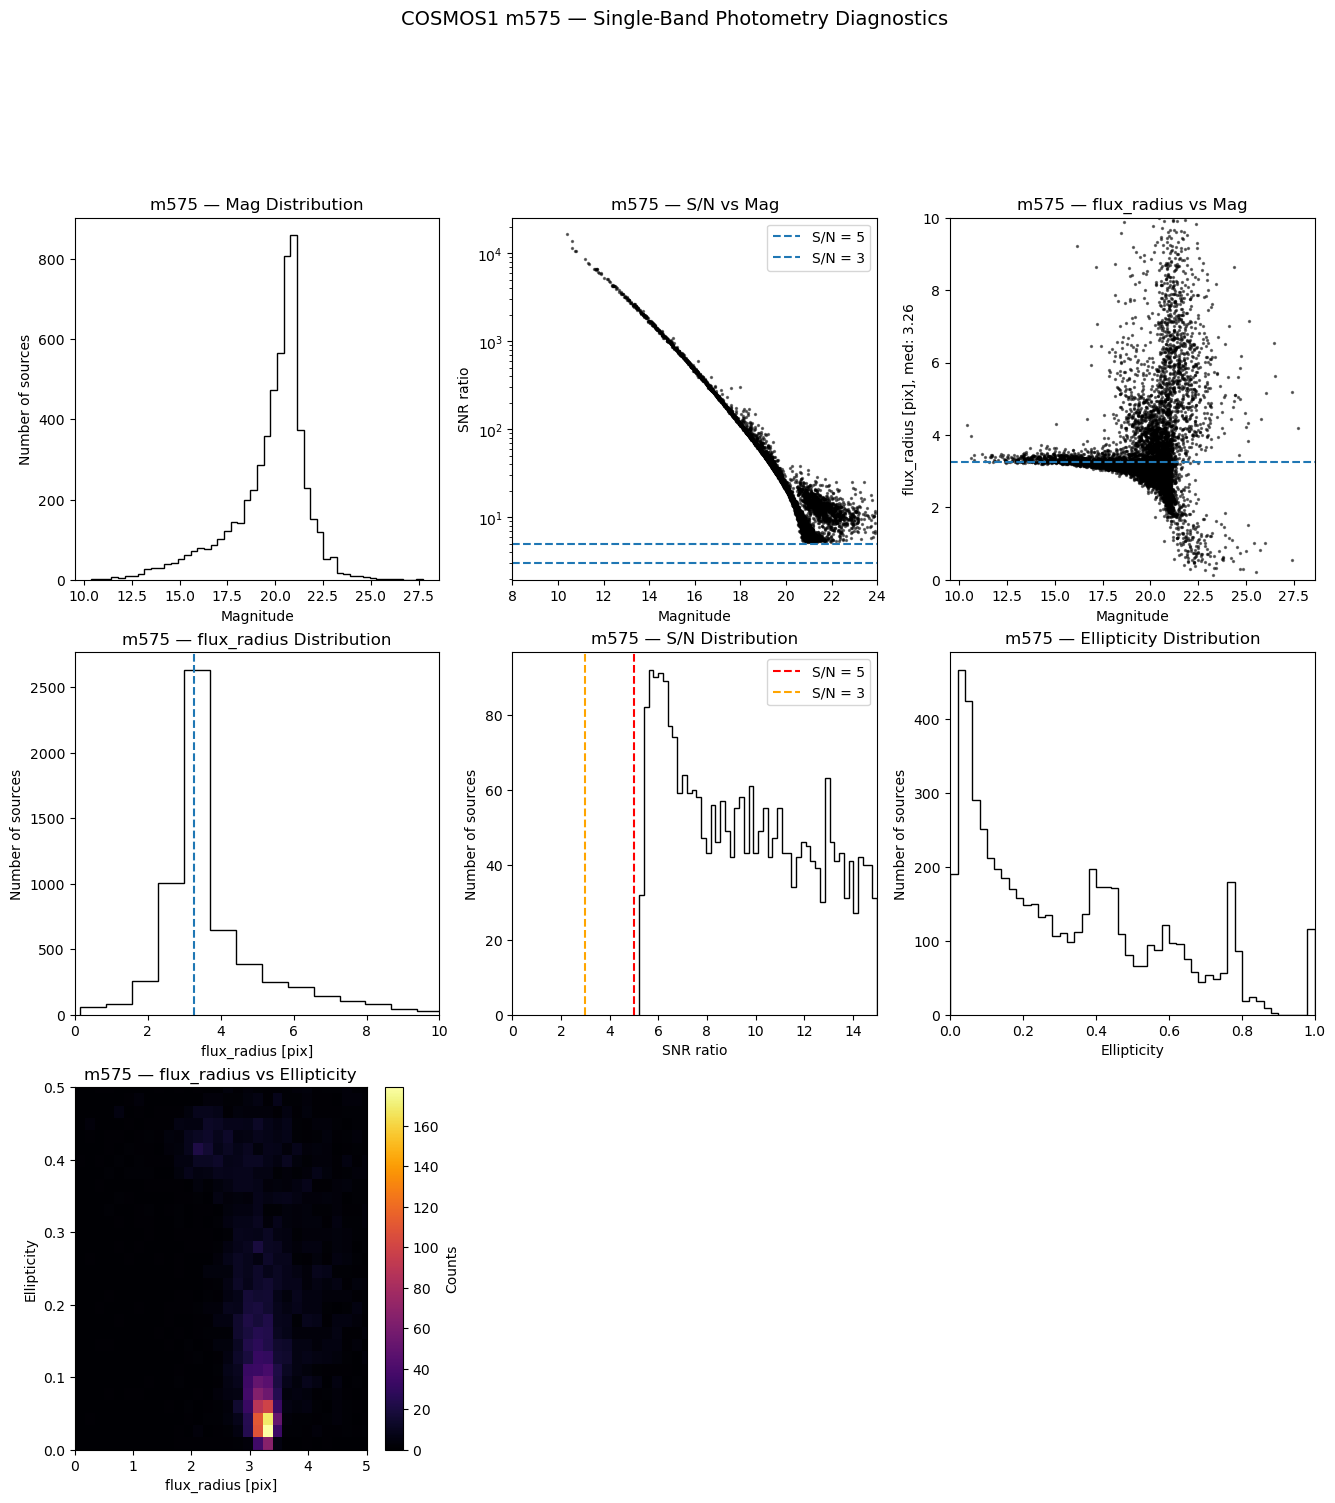

In [3]:
save_dir = PROJECT_ROOT / f"output/COSMOS{COSMOS}/singlebandphot/figures"
save_dir.mkdir(parents=True, exist_ok=True)

for band in tqdm(available_band):
    catalog_path = (
        PROJECT_ROOT
        / f"output/COSMOS{COSMOS}/singlebandphot"
        / f"cat_cosmos{COSMOS}_{band}.fits"
    )
    
    cat = Table.read(catalog_path)
    cat = cat[cat['aper3_flags']==0]
    
    # valid_mask filtering
    cat_x = np.rint(cat['pixel_centroid_x']).astype(int)
    cat_y = np.rint(cat['pixel_centroid_y']).astype(int)
    valid_source = valid_mask[cat_y, cat_x]
    cat = cat[valid_source]
    cat = cat[(cat['aper3_flags']==0) & (cat['flux_radius'] > 0) & (cat['aper3_mag'] > 5)]
    
    print(f'{band}: {len(cat)} good sources')
    
    # --- 3x3 subplot ---
    mag = np.asarray(cat['aper3_mag'])
    snr = np.asarray(cat['snrratio'])
    flux_radius = np.asarray(cat['flux_radius'])
    ellipticity = np.asarray(cat['ellipticity'])
    
    # --- calculate flux_radius median ---
    r50_mean, r50_med, r50_std = sigma_clipped_stats(flux_radius)
    
    fig, axes = plt.subplots(3, 3, figsize=(16, 16))
    
    # --- [0,0] Magnitude Histogram ---
    axes[0,0].hist(mag, bins=50, histtype='step', color='black')
    axes[0,0].set_xlabel("Magnitude")
    axes[0,0].set_ylabel("Number of sources")
    axes[0,0].set_title(f"{band} — Mag Distribution")
    
    # --- [0,1] SNR vs Magnitude ---
    axes[0,1].scatter(mag, snr, s=2, marker='o', alpha=0.5, color='black')
    axes[0,1].set_xlabel("Magnitude")
    axes[0,1].set_ylabel("SNR ratio")
    axes[0,1].set_yscale('log')
    axes[0,1].set_xlim(8, 24)
    axes[0,1].axhline(5, linestyle="--", label="S/N = 5")
    axes[0,1].axhline(3, linestyle="--", label="S/N = 3")
    axes[0,1].legend()
    axes[0,1].set_title(f"{band} — S/N vs Mag")
    
    # --- [0,2] flux_radius vs Magnitude ---
    axes[0,2].scatter(mag, flux_radius, s=2, marker='o', alpha=0.5, color='black')
    axes[0,2].set_xlabel("Magnitude")
    axes[0,2].set_ylabel(f"flux_radius [pix], med: {r50_med:.2f}")
    axes[0,2].set_ylim(0, 10)
    axes[0,2].axhline(r50_med, linestyle="--")
    axes[0,2].set_title(f"{band} — flux_radius vs Mag")
    
    # --- [1,0] flux_radius Histogram ---
    axes[1,0].hist(flux_radius, bins=100, histtype='step', color='black')
    axes[1,0].axvline(r50_med, linestyle="--", label="r50_median")
    axes[1,0].set_xlabel("flux_radius [pix]")
    axes[1,0].set_ylabel("Number of sources")
    axes[1,0].set_title(f"{band} — flux_radius Distribution")
    axes[1,0].set_xlim(0, 10)
    
    # --- [1,1] S/N Histogram ---
    snr_hist = snr[snr<15]
    axes[1,1].hist(snr_hist, bins=50, histtype='step', color='black')
    axes[1,1].set_xlabel("SNR ratio")
    axes[1,1].set_ylabel("Number of sources")
    axes[1,1].set_title(f"{band} — S/N Distribution")
    axes[1,1].axvline(5, linestyle="--", color='red', label="S/N = 5")
    axes[1,1].axvline(3, linestyle="--", color='orange', label="S/N = 3")
    axes[1,1].set_xlim(0, 15)
    axes[1,1].legend()
    
    # --- [1,2] Ellipticity Histogram ---
    axes[1,2].hist(ellipticity, bins=50, histtype='step', color='black')
    axes[1,2].set_xlabel("Ellipticity")
    axes[1,2].set_ylabel("Number of sources")
    axes[1,2].set_title(f"{band} — Ellipticity Distribution")
    axes[1,2].set_xlim(0, 1)
    
    # --- [2,0] flux_radius vs Ellipticity 2D Histogram ---
    h = axes[2,0].hist2d(
        flux_radius, ellipticity,
        bins=[np.linspace(0, 10, 60), np.linspace(0, 1, 60)],
        cmap='inferno'
    )
    plt.colorbar(h[3], ax=axes[2,0], label="Counts")
    axes[2,0].set_xlabel("flux_radius [pix]")
    axes[2,0].set_ylabel("Ellipticity")
    axes[2,0].set_title(f"{band} — flux_radius vs Ellipticity")
    axes[2,0].set_xlim(0, 5)
    axes[2,0].set_ylim(0, 0.5)
    
    # --- Hide unused subplots ---
    axes[2,1].axis('off')
    axes[2,2].axis('off')
    
    fig.suptitle(f"COSMOS{COSMOS} {band} — Single-Band Photometry Diagnostics", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.savefig(save_dir / f'info_{band}.png', dpi=150, bbox_inches='tight')
    plt.close()
    


plot image and detected sources & compare with detection image in multi-band phot

['source_id', 'detection_id', 'pixel_centroid_x', 'pixel_centroid_y', 'world_centroid_alpha', 'world_centroid_delta', 'aper3_flux', 'aper3_flux_err', 'aper3_mag', 'aper3_mag_err', 'aper3_flags', 'snrratio', 'ellipse_a', 'ellipse_b', 'ellipse_theta', 'ellipse_cxx', 'ellipse_cyy', 'ellipse_cxy', 'area', 'elongation', 'ellipticity', 'flux_radius']
Detected Sources : 7888


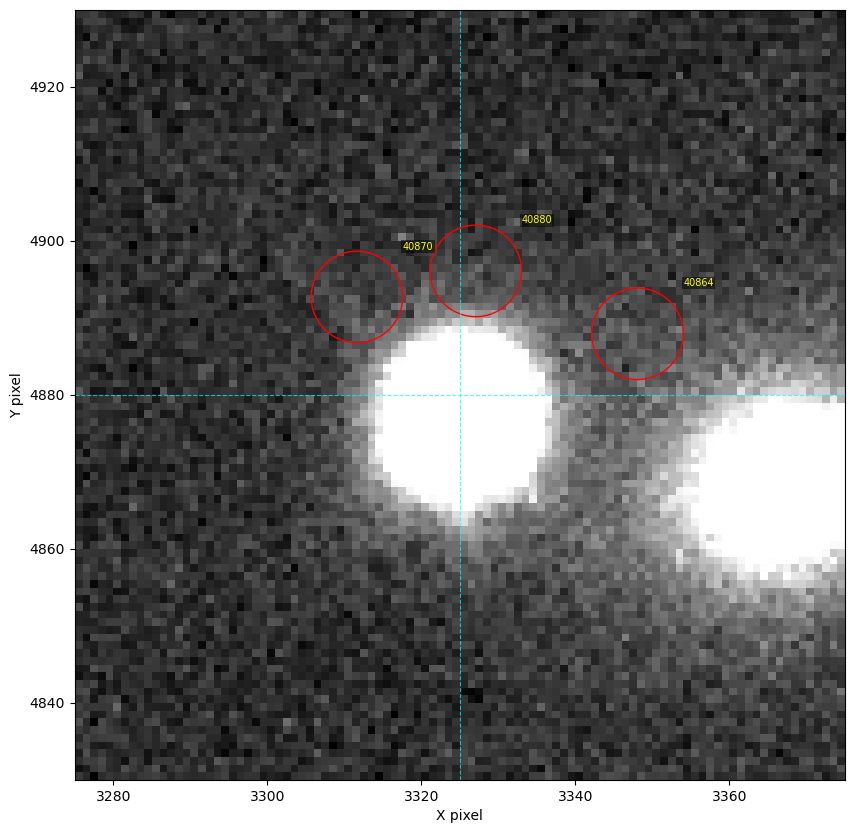


        idx : 1302 
        source_id : 38942
        mag : 20.421768188476562 
        snr : 9.003372192382812
        flux_radius : 2.974477529525757
        ellipticity : 0.5829224586486816
        


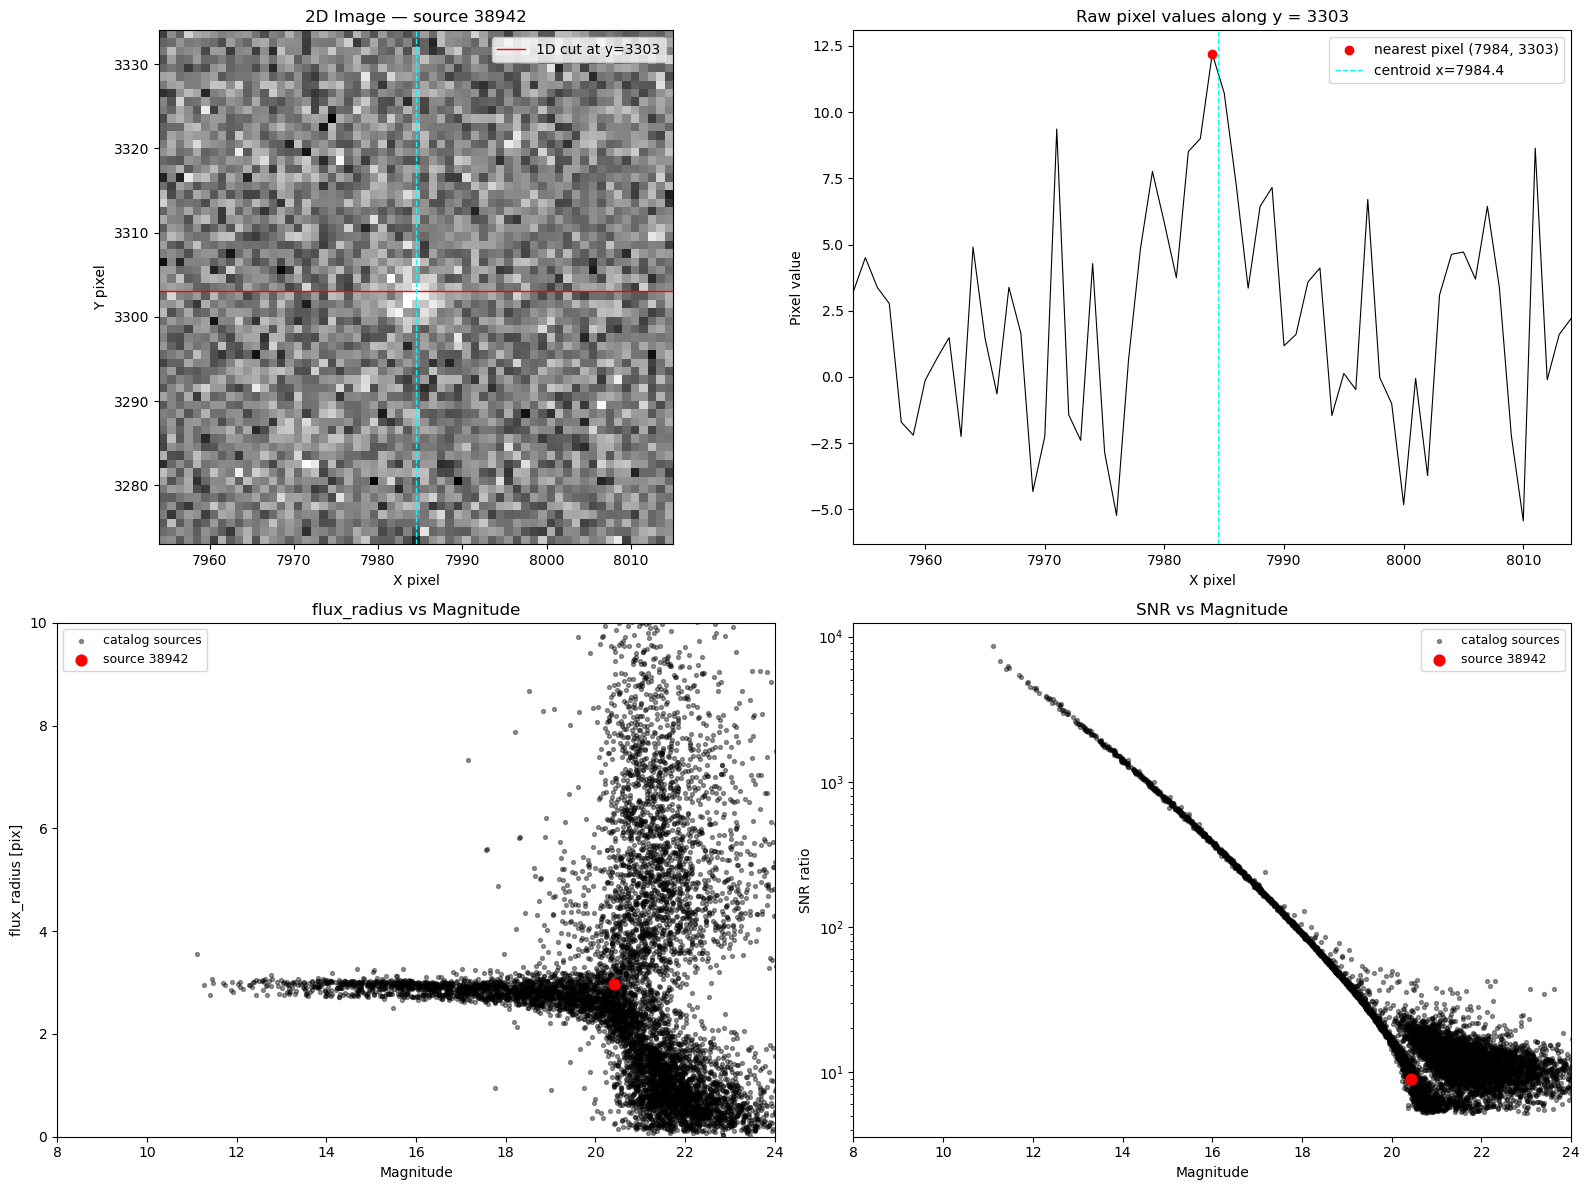

In [4]:
def plot_SourceExampleInCatalog(image, cat, length=10, source_id=None, selection=None):
    cat_original = cat
    if selection is not None : 
        cat = cat[selection]
    
    if source_id is None:
        idx = random.randrange(len(cat))
    else:
        idx = np.where(cat['source_id'] == source_id)[0]
        if len(idx) > 0:
            idx = idx[0]
        else:
            raise ValueError(f'{source_id} not found in catalog')

    print(
        f'''
        idx : {idx} 
        source_id : {cat['source_id'][idx]}
        mag : {cat['aper3_mag'][idx]} 
        snr : {cat['snrratio'][idx]}
        flux_radius : {cat['flux_radius'][idx]}
        ellipticity : {cat['ellipticity'][idx]}
        '''
    )
    
    xlim = image.shape[1]
    ylim = image.shape[0]

    center_point_x = float(cat['pixel_centroid_x'][idx])
    center_point_y = float(cat['pixel_centroid_y'][idx])
    x_center = int(np.rint(center_point_x))
    y_cut = int(np.rint(center_point_y))

    if not (0 <= x_center < xlim and 0 <= y_cut < ylim):
        raise ValueError(
            f'Source centroid is outside the image: '
            f'x={center_point_x}, y={center_point_y}'
        )

    xmin = max(0, x_center - length)
    xmax = min(xlim, x_center + length + 1)
    ymin = max(0, y_cut - length)
    ymax = min(ylim, y_cut + length + 1)
    
    image_plot = image[ymin:ymax, xmin:xmax]
    
    # --- 1D pixel cut along the exact horizontal crosshair row ---
    x_pixels = np.arange(xmin, xmax)
    pixel_values = np.asarray(image[y_cut, xmin:xmax], dtype=float)
    
    # --- 2D image, 1D profile, and catalog diagnostics ---
    fig, axes = plt.subplots(2, 2, figsize=(16, 12),
                         gridspec_kw={'width_ratios': [1, 1]})
    ax_img, ax_1d = axes[0]
    ax_flux, ax_snr = axes[1]
    
    # 1. 2D pixel Plot
    norm = ImageNormalize(
        image_plot,
        interval=ZScaleInterval(),
    )

    ax_img.imshow(
        image_plot,
        cmap='gray',
        norm=norm,
        origin='lower',
        extent=[xmin, xmax, ymin, ymax],
    )
    ax_img.axhline(y=y_cut, color='red', linestyle='-', linewidth=1,
                   label=f'1D cut at y={y_cut}')
    ax_img.axvline(x=center_point_x, color='cyan', linestyle='--', linewidth=1)
    ax_img.legend(fontsize=10, loc='upper right')
    ax_img.set_xlabel('X pixel')
    ax_img.set_ylabel('Y pixel')
    ax_img.set_title(f'2D Image — source {cat["source_id"][idx]}')
    
    # 2. 1D pixel graph (horizontal cut)
    ax_1d.plot(x_pixels, pixel_values, color='black', linewidth=0.8)
    ax_1d.scatter(x_center, image[y_cut, x_center], color='red', zorder=3,
                  label=f'nearest pixel ({x_center}, {y_cut})')
    ax_1d.axvline(x=center_point_x, color='cyan', linestyle='--', linewidth=1,
                  label=f'centroid x={center_point_x:.1f}')
    ax_1d.set_xlabel('X pixel')
    ax_1d.set_ylabel('Pixel value')
    ax_1d.set_xlim(xmin, xmax - 1)
    ax_1d.set_title(f'Raw pixel values along y = {y_cut}')
    ax_1d.legend(fontsize=10)
    
    # 3. flux_radius vs magnitude
    mag = np.asarray(cat_original['aper3_mag'], dtype=float)
    flux_radius = np.asarray(cat_original['flux_radius'], dtype=float)
    snr = np.asarray(cat_original['snrratio'], dtype=float)

    valid_flux = np.isfinite(mag) & np.isfinite(flux_radius)
    valid_snr = np.isfinite(mag) & np.isfinite(snr) & (snr > 0)

    ax_flux.scatter(
        mag[valid_flux],
        flux_radius[valid_flux],
        s=8,
        alpha=0.4,
        color='black',
        label='catalog sources',
    )
    ax_flux.scatter(
        cat['aper3_mag'][idx],
        cat['flux_radius'][idx],
        s=60,
        color='red',
        zorder=5,
        label=f"source {cat['source_id'][idx]}",
    )
    ax_flux.set_xlabel('Magnitude')
    ax_flux.set_ylabel('flux_radius [pix]')
    ax_flux.set_title('flux_radius vs Magnitude')
    ax_flux.set_xlim(8, 24)
    ax_flux.set_ylim(0, 10)
    ax_flux.legend(fontsize=9)

    # 4. SNR vs magnitude
    ax_snr.scatter(
        mag[valid_snr],
        snr[valid_snr],
        s=8,
        alpha=0.4,
        color='black',
        label='catalog sources',
    )
    ax_snr.scatter(
        cat['aper3_mag'][idx],
        cat['snrratio'][idx],
        s=60,
        color='red',
        zorder=5,
        label=f"source {cat['source_id'][idx]}",
    )
    ax_snr.set_xlabel('Magnitude')
    ax_snr.set_ylabel('SNR ratio')
    ax_snr.set_title('SNR vs Magnitude')
    ax_snr.set_yscale('log')
    ax_snr.set_xlim(8, 24)
    ax_snr.legend(fontsize=9)
    
    plt.tight_layout()
    plt.show()

# ================== Setting ======================

test_band = 'm450'
catalog_path = get_catalog_path(COSMOS, test_band)
cat = Table.read(catalog_path)
print(cat.colnames)

# Noise Level Test
good = (
    (cat['aper3_flags'] == 0)
    & np.isfinite(cat['aper3_mag'])
    & (cat['aper3_mag'] > 2)
    & np.isfinite(cat['snrratio'])
    & np.isfinite(cat['flux_radius'])
    & (cat['flux_radius'] > 0)
)

cat = cat[good] 

print(f'Detected Sources : {len(cat)}')

image_path = get_image_path(COSMOS, test_band)
image = fits.getdata(image_path)

plot_ImageAndDetectedSources(image, cat, center_point=[3325, 4880], length=100)

selection = (cat['snrratio']<10)
plot_SourceExampleInCatalog(
    image, cat, 
    length=30, 
    source_id=38942,
    selection=selection
)

# plot_SourceExampleInCatalog(
#     image, cat, 
#     length=10,
#     source_id=40870
# )
# plot_SourceExampleInCatalog(
#     image, cat, 
#     length=10,
#     source_id=40880
# )
# plot_SourceExampleInCatalog(
#     image, cat, 
#     length=10,
#     source_id=40864
# )


For reference : Detection image used in multi-band catalog

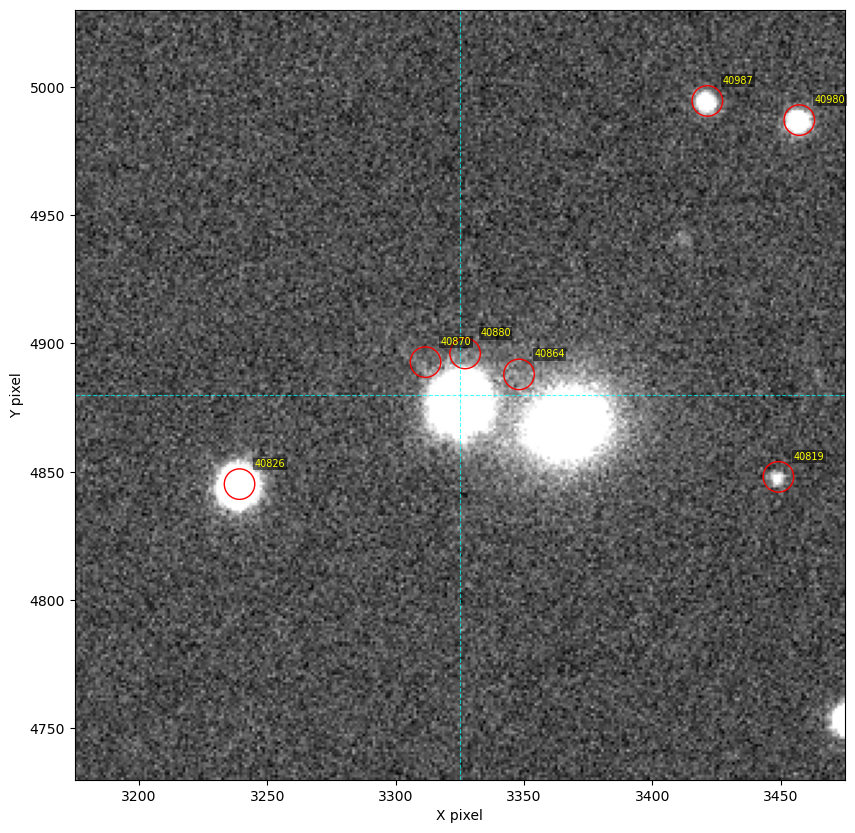

multi-band detected sources : 21687


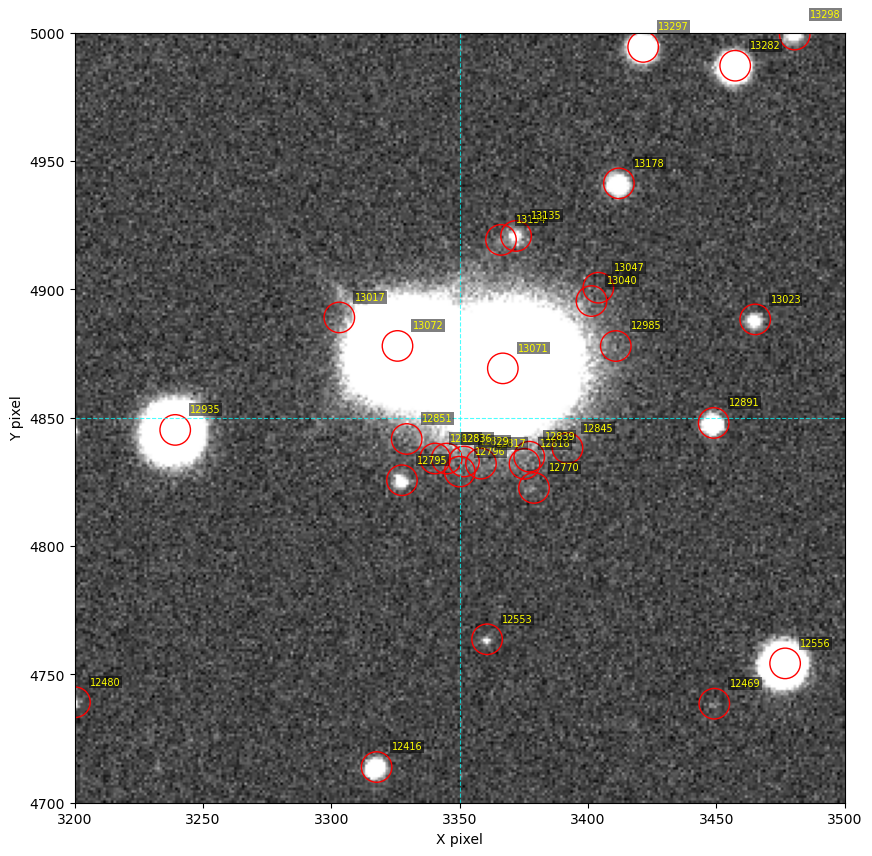

In [3]:

plot_ImageAndDetectedSources(image, cat, center_point=[3325, 4880], length=300)

detection_image_path = Path('/Users/mac_seo/Research_local/7DTonCOSMOS/COSMOS_data/COSMOS1/COSMOS1_detectionimage.fits')
detection_image = fits.getdata(detection_image_path)
cat_multiband = Table.read('/Users/mac_seo/Research_local/7DTonCOSMOS/output/COSMOS1/multibandphot/test_catalog.fits')
print(f'multi-band detected sources : {len(cat_multiband)}')
plot_ImageAndDetectedSources(detection_image, cat_multiband, center_point=[3350, 4850], length=300)

# 3. Matching

### 3.1 Per-band FWHM and positional uncertainty

Approved observation-based estimate (same working catalog as the single-band diagnostics):

- `r50_mean, r50_med, r50_std = sigma_clipped_stats(flux_radius)`
- `FWHM_i [pix] = 2 * r50_med,i` (circular 2D Gaussian, `flux_radius` = 50%-flux radius)
- `min_snrratio_i` = minimum finite, strictly positive `snrratio` in the same working catalog
- `sigma_i [pix] = FWHM_i / (2.355 * min_snrratio_i)`

No source-by-source S/N is used. No S/N cut is applied.


In [4]:
# 3.1 Per-band working catalogs, FWHM and sigma_i (same cuts as the diagnostics cell)
catalogs = {}
matching_catalogs = {}
r50_statistics = {}
band_fwhm = {}
band_snrratio_min = {}
band_sigma = {}
band_sigma_arcsec = {}
band_matching_count = {}
band_snr_invalid_count = {}

pixel_scale_value = float(PIXEL_SCALE.value)  # arcsec / pix

for band in tqdm(available_band):
    catalog_path = (
        PROJECT_ROOT
        / f"output/COSMOS{COSMOS}/singlebandphot"
        / f"cat_cosmos{COSMOS}_{band}.fits"
    )
    cat_full = Table.read(catalog_path)
    catalogs[band] = cat_full

    # Same quality cuts as the diagnostics cell, plus a minimal bounds guard
    # so out-of-image centroids cannot index valid_mask.
    cat = cat_full[cat_full['aper3_flags'] == 0]
    cat_x_all = np.rint(np.asarray(cat['pixel_centroid_x'], dtype=float)).astype(int)
    cat_y_all = np.rint(np.asarray(cat['pixel_centroid_y'], dtype=float)).astype(int)
    inside = (
        (cat_x_all >= 0) & (cat_x_all < valid_mask.shape[1])
        & (cat_y_all >= 0) & (cat_y_all < valid_mask.shape[0])
    )
    cat = cat[inside]
    cat_x_all = cat_x_all[inside]
    cat_y_all = cat_y_all[inside]
    valid_source = valid_mask[cat_y_all, cat_x_all]
    cat = cat[valid_source]
    cat = cat[
        (cat['aper3_flags'] == 0)
        & (np.asarray(cat['flux_radius'], dtype=float) > 0)
        & (np.asarray(cat['aper3_mag'], dtype=float) > 5)
    ]
    matching_catalogs[band] = cat

    flux_radius = np.asarray(cat['flux_radius'], dtype=float)
    r50_mean, r50_med, r50_std = sigma_clipped_stats(flux_radius)
    r50_statistics[band] = (float(r50_mean), float(r50_med), float(r50_std))
    if not (np.isfinite(r50_med) and float(r50_med) > 0):
        raise ValueError(f"{band}: invalid r50_med={r50_med}; cannot define FWHM.")
    fwhm_pix = 2.0 * float(r50_med)
    band_fwhm[band] = fwhm_pix

    snr = np.asarray(cat['snrratio'], dtype=float)
    n_invalid = int((~np.isfinite(snr)).sum())
    n_nonpos = int(((snr <= 0) & np.isfinite(snr)).sum())
    band_snr_invalid_count[band] = (n_invalid, n_nonpos)
    valid_snr = snr[np.isfinite(snr) & (snr > 0)]
    if valid_snr.size == 0:
        raise ValueError(f"{band}: no finite positive snrratio; cannot define sigma_i.")
    min_snr = float(valid_snr.min())
    band_snrratio_min[band] = min_snr

    sigma_pix = fwhm_pix / (2.355 * min_snr)
    band_sigma[band] = float(sigma_pix)
    band_sigma_arcsec[band] = float(sigma_pix * pixel_scale_value)
    band_matching_count[band] = len(cat)
    print(
        f"{band}: n={len(cat)} r50_med={float(r50_med):.3f} pix "
        f"FWHM={fwhm_pix:.3f} pix min_snr={min_snr:.3f} "
        f"sigma={sigma_pix:.4f} pix ({sigma_pix * pixel_scale_value:.4f} arcsec) "
        f"snr_invalid={n_invalid} snr_nonpos={n_nonpos}"
    )


  0%|          | 0/20 [00:00<?, ?it/s]

m400: n=1815 r50_med=2.585 pix FWHM=5.171 pix min_snr=5.081 sigma=0.4321 pix (0.2182 arcsec) snr_invalid=0 snr_nonpos=0
m425: n=3452 r50_med=2.875 pix FWHM=5.749 pix min_snr=5.203 sigma=0.4692 pix (0.2369 arcsec) snr_invalid=0 snr_nonpos=0
m450: n=2467 r50_med=2.827 pix FWHM=5.655 pix min_snr=5.208 sigma=0.4611 pix (0.2329 arcsec) snr_invalid=0 snr_nonpos=0
m475: n=4163 r50_med=2.980 pix FWHM=5.959 pix min_snr=5.172 sigma=0.4893 pix (0.2471 arcsec) snr_invalid=0 snr_nonpos=0
m500: n=4003 r50_med=2.435 pix FWHM=4.869 pix min_snr=5.138 sigma=0.4024 pix (0.2032 arcsec) snr_invalid=0 snr_nonpos=0
m525: n=5347 r50_med=2.708 pix FWHM=5.417 pix min_snr=5.174 sigma=0.4445 pix (0.2245 arcsec) snr_invalid=0 snr_nonpos=0
m550: n=2934 r50_med=3.063 pix FWHM=6.127 pix min_snr=5.223 sigma=0.4981 pix (0.2515 arcsec) snr_invalid=0 snr_nonpos=0
m575: n=6002 r50_med=3.259 pix FWHM=6.518 pix min_snr=5.213 sigma=0.5310 pix (0.2681 arcsec) snr_invalid=0 snr_nonpos=0
m600: n=3146 r50_med=2.838 pix FWHM=5.67

### 3.2 Recursive inverse-variance weighted matcher

- Master position = inverse-variance centroid of ALL accepted detections.
- New band is compared to CURRENT master centroids (snapshot per band), not to the previous band only.
- Positional gate: `separation < 3 * sqrt(sigma_master^2 + sigma_band^2)` in pixel coordinates.
- Magnitude (`aper3_mag`) is a tie-breaker only; normalized separation `D` is the fallback.
- One incoming detection maps to at most one master; one master takes at most one detection per band.


In [ ]:
# 3.2 Recursive inverse-variance weighted cross-band matcher (pixel coordinates)
import numpy as np
try:
    from scipy.spatial import cKDTree
    _HAVE_KDTREE = True
except Exception:
    _HAVE_KDTREE = False

K_MATCH = 3

def band_wavelength(band):
    return int(band[1:])

def is_usable_mag(m):
    try:
        m = float(m)
    except Exception:
        return False
    return bool(np.isfinite(m) and m != 0.0)

def select_reference_band(master, new_band):
    """Nearest already-associated band with a usable aper3_mag. Returns (ref_band, ref_mag)."""
    new_wl = band_wavelength(new_band)
    best = None
    for b in master['magnitudes_by_band']:
        m = master['magnitudes_by_band'][b]
        if not is_usable_mag(m):
            continue
        d = abs(band_wavelength(b) - new_wl)
        key = (d, band_wavelength(b))
        if best is None or key < best[0]:
            best = (key, b, float(m))
    if best is None:
        return None, float('nan')
    return best[1], best[2]

def update_master_state(master, x, y, sigma_band, band, source_id, mag):
    w = 1.0 / (float(sigma_band) ** 2)
    master['sum_w'] += w
    master['sum_wx'] += w * float(x)
    master['sum_wy'] += w * float(y)
    master['x'] = master['sum_wx'] / master['sum_w']
    master['y'] = master['sum_wy'] / master['sum_w']
    master['sigma_master'] = 1.0 / np.sqrt(master['sum_w'])
    master['source_ids_by_band'][band] = int(source_id)
    master['magnitudes_by_band'][band] = float(mag)
    master['members'].append({
        'band': band, 'source_id': int(source_id),
        'x': float(x), 'y': float(y),
        'sigma_band': float(sigma_band), 'mag': float(mag),
    })

def new_master_state(x, y, sigma_band, band, source_id, mag):
    w = 1.0 / (float(sigma_band) ** 2)
    return {
        'master_id': None,
        'sum_w': w, 'sum_wx': w * float(x), 'sum_wy': w * float(y),
        'x': float(x), 'y': float(y),
        'sigma_master': float(sigma_band),
        'source_ids_by_band': {band: int(source_id)},
        'magnitudes_by_band': {band: float(mag)},
        'members': [{
            'band': band, 'source_id': int(source_id),
            'x': float(x), 'y': float(y),
            'sigma_band': float(sigma_band), 'mag': float(mag),
        }],
    }

# --- initialize from the first processed band ---
if len(available_band) == 0:
    raise ValueError("available_band is empty; cannot initialize masters.")
first_processed_band = available_band[0]
print(f"First processed band: {first_processed_band}")

master_states = []
cat0 = matching_catalogs[first_processed_band]
sig0 = band_sigma[first_processed_band]
for row in cat0:
    m = new_master_state(
        row['pixel_centroid_x'], row['pixel_centroid_y'], sig0,
        first_processed_band, row['source_id'], row['aper3_mag'],
    )
    m['master_id'] = len(master_states)
    master_states.append(m)

matching_diagnostic_rows = []
for m in master_states:
    mem = m['members'][0]
    matching_diagnostic_rows.append({
        'band': first_processed_band, 'source_id': mem['source_id'],
        'master_id': m['master_id'], 'candidate_master_id': m['master_id'],
        'source_x': mem['x'], 'source_y': mem['y'],
        'source_ra': float(cat0[cat0['source_id'] == mem['source_id']]['world_centroid_alpha'][0]),
        'source_dec': float(cat0[cat0['source_id'] == mem['source_id']]['world_centroid_delta'][0]),
        'sigma_band': mem['sigma_band'],
        'master_x_at_match': mem['x'], 'master_y_at_match': mem['y'],
        'sigma_master_at_match': mem['sigma_band'],
        'separation': 0.0, 'sigma_match': mem['sigma_band'],
        'normalized_separation': 0.0, 'number_of_positional_candidates': 1,
        'magnitude_reference_band': '', 'magnitude_difference': float('nan'),
        'ambiguous': False, 'candidate_rank': 0, 'selected': True,
        'match_status': 'initialized',
    })

# --- process remaining bands sequentially ---
for band in tqdm(available_band[1:]):
    cat = matching_catalogs[band]
    sigma_band = band_sigma[band]
    n_in = len(cat)
    if n_in == 0:
        continue
    xs = np.asarray(cat['pixel_centroid_x'], dtype=float)
    ys = np.asarray(cat['pixel_centroid_y'], dtype=float)
    mags = np.asarray(cat['aper3_mag'], dtype=float)
    sids = np.asarray(cat['source_id']).astype(int)
    ra = np.asarray(cat['world_centroid_alpha'], dtype=float)
    dec = np.asarray(cat['world_centroid_delta'], dtype=float)

    # Snapshot of current master centroids (detections within this band do not see each other).
    mx = np.array([m['x'] for m in master_states], dtype=float)
    my = np.array([m['y'] for m in master_states], dtype=float)
    msig = np.array([m['sigma_master'] for m in master_states], dtype=float)

    # Candidate generation: conservative radius, then exact per-candidate gate.
    if _HAVE_KDTREE and len(master_states) > 0:
        tree = cKDTree(np.column_stack([mx, my]))
        rmax = K_MATCH * float(np.sqrt(np.max(msig) ** 2 + sigma_band ** 2))
        ball = tree.query_ball_point(np.column_stack([xs, ys]), r=rmax)
    else:
        # Blockwise brute force (no new dependency, no full N x M matrix).
        ball = []
        blk = 2000
        for s in range(0, n_in, blk):
            e = min(n_in, s + blk)
            dx = xs[s:e, None] - mx[None, :]
            dy = ys[s:e, None] - my[None, :]
            dd = np.hypot(dx, dy)
            rmax = K_MATCH * np.sqrt(msig[None, :] ** 2 + sigma_band ** 2)
            for k in range(e - s):
                ball.append(list(np.where(dd[k] <= rmax[k])[0]))

    edges = {}  # incoming idx -> list of edge dicts passing the exact gate
    for i in range(n_in):
        elist = []
        for j in ball[i]:
            sm = float(np.sqrt(msig[j] ** 2 + sigma_band ** 2))
            sep = float(np.hypot(xs[i] - mx[j], ys[i] - my[j]))
            if sep < K_MATCH * sm:
                D = sep / sm
                ref_band, ref_mag = select_reference_band(master_states[j], band)
                if is_usable_mag(mags[i]) and ref_band is not None:
                    dm = float(abs(float(mags[i]) - float(ref_mag)))
                else:
                    dm = float('nan')
                    ref_band = ref_band if ref_band is not None else ''
                elist.append({
                    'master': int(j), 'sep': sep, 'sm': sm, 'D': float(D),
                    'ref_band': ref_band if isinstance(ref_band, str) and ref_band == '' else (ref_band if ref_band is not None else ''),
                    'dm': dm,
                })
        # Rank: magnitude difference first (when usable), else normalized separation; deterministic by master_id.
        def _rank(e):
            has_mag = np.isfinite(e['dm'])
            return (0 if has_mag else 1, e['dm'] if has_mag else e['D'], e['master'])
        elist.sort(key=_rank)
        for r, e in enumerate(elist):
            e['rank'] = r
        edges[i] = elist

    assigned_incoming = {}  # incoming idx -> master idx
    taken_masters = set()

    # Stage 1: positionally unique detections first (preserves unambiguous matches).
    unique_idx = [i for i, el in edges.items() if len(el) == 1]
    # Deterministic: smallest D first so conflicts resolve identically on re-run.
    unique_idx.sort(key=lambda i: (edges[i][0]['D'], i))
    for i in unique_idx:
        j = edges[i][0]['master']
        if j in taken_masters:
            continue  # conflict -> new master below
        assigned_incoming[i] = j
        taken_masters.add(j)

    # Stage 2: ambiguous detections; best magnitude (else best D) wins a free master.
    def _best_score(i):
        e = edges[i][0]
        has_mag = np.isfinite(e['dm'])
        return (0 if has_mag else 1, e['dm'] if has_mag else e['D'], i)
    amb_idx = [i for i, el in edges.items() if len(el) > 1]
    amb_idx.sort(key=_best_score)
    for i in amb_idx:
        if i in assigned_incoming:
            continue
        for e in edges[i]:
            if e['master'] not in taken_masters:
                assigned_incoming[i] = e['master']
                taken_masters.add(e['master'])
                break

    # Apply assignments, update masters, write diagnostics.
    for i in range(n_in):
        elist = edges[i]
        n_cand = len(elist)
        if i in assigned_incoming:
            j = assigned_incoming[i]
            m = master_states[j]
            mx0, my0, ms0 = float(m['x']), float(m['y']), float(m['sigma_master'])
            sm = float(np.sqrt(ms0 ** 2 + sigma_band ** 2))
            sep = float(np.hypot(xs[i] - mx0, ys[i] - my0))
            D = sep / sm
            e = next(e for e in elist if e['master'] == j)
            ambiguous = n_cand > 1
            if not ambiguous:
                status = 'matched_unique'
            elif np.isfinite(e['dm']):
                status = 'matched_magnitude'
            else:
                status = 'matched_position_fallback'
            for e2 in elist:
                matching_diagnostic_rows.append({
                    'band': band, 'source_id': int(sids[i]),
                    'master_id': int(j), 'candidate_master_id': int(e2['master']),
                    'source_x': float(xs[i]), 'source_y': float(ys[i]),
                    'source_ra': float(ra[i]), 'source_dec': float(dec[i]),
                    'sigma_band': float(sigma_band),
                    'master_x_at_match': mx0, 'master_y_at_match': my0,
                    'sigma_master_at_match': ms0,
                    'separation': float(np.hypot(xs[i] - mx[e2['master']], ys[i] - my[e2['master']])),
                    'sigma_match': float(np.sqrt(msig[e2['master']] ** 2 + sigma_band ** 2)),
                    'normalized_separation': float(np.hypot(xs[i] - mx[e2['master']], ys[i] - my[e2['master']]) / np.sqrt(msig[e2['master']] ** 2 + sigma_band ** 2)),
                    'number_of_positional_candidates': n_cand,
                    'magnitude_reference_band': e2['ref_band'] if isinstance(e2['ref_band'], str) else (e2['ref_band'] or ''),
                    'magnitude_difference': float(e2['dm']),
                    'ambiguous': ambiguous, 'candidate_rank': int(e2['rank']),
                    'selected': bool(e2['master'] == j),
                    'match_status': status if e2['master'] == j else 'rejected_one_to_one',
                })
            update_master_state(m, xs[i], ys[i], sigma_band, band, sids[i], mags[i])
        else:
            if n_cand == 0:
                status = 'new_master_no_candidate'
            else:
                status = 'new_master_conflict'
                for e2 in elist:
                    matching_diagnostic_rows.append({
                        'band': band, 'source_id': int(sids[i]),
                        'master_id': -1, 'candidate_master_id': int(e2['master']),
                        'source_x': float(xs[i]), 'source_y': float(ys[i]),
                        'source_ra': float(ra[i]), 'source_dec': float(dec[i]),
                        'sigma_band': float(sigma_band),
                        'master_x_at_match': float(mx[e2['master']]),
                        'master_y_at_match': float(my[e2['master']]),
                        'sigma_master_at_match': float(msig[e2['master']]),
                        'separation': float(np.hypot(xs[i] - mx[e2['master']], ys[i] - my[e2['master']])),
                        'sigma_match': float(np.sqrt(msig[e2['master']] ** 2 + sigma_band ** 2)),
                        'normalized_separation': float(np.hypot(xs[i] - mx[e2['master']], ys[i] - my[e2['master']]) / np.sqrt(msig[e2['master']] ** 2 + sigma_band ** 2)),
                        'number_of_positional_candidates': n_cand,
                        'magnitude_reference_band': e2['ref_band'] if isinstance(e2['ref_band'], str) else (e2['ref_band'] or ''),
                        'magnitude_difference': float(e2['dm']),
                        'ambiguous': n_cand > 1, 'candidate_rank': int(e2['rank']),
                        'selected': False, 'match_status': 'rejected_one_to_one',
                    })
            m = new_master_state(xs[i], ys[i], sigma_band, band, sids[i], mags[i])
            m['master_id'] = len(master_states)
            master_states.append(m)
            matching_diagnostic_rows.append({
                'band': band, 'source_id': int(sids[i]),
                'master_id': int(m['master_id']), 'candidate_master_id': int(m['master_id']),
                'source_x': float(xs[i]), 'source_y': float(ys[i]),
                'source_ra': float(ra[i]), 'source_dec': float(dec[i]),
                'sigma_band': float(sigma_band),
                'master_x_at_match': float('nan'), 'master_y_at_match': float('nan'),
                'sigma_master_at_match': float('nan'),
                'separation': float('nan'), 'sigma_match': float('nan'),
                'normalized_separation': float('nan'),
                'number_of_positional_candidates': n_cand,
                'magnitude_reference_band': '', 'magnitude_difference': float('nan'),
                'ambiguous': n_cand > 1, 'candidate_rank': -1, 'selected': True,
                'match_status': status,
            })

print(f"masters: {len(master_states)}  diagnostic rows: {len(matching_diagnostic_rows)}")

# --- wide source-ID association table (masked integers preserve original source_id) ---
matching_table = Table(masked=True)
matching_table['master_id'] = np.arange(len(master_states), dtype=np.int64)
for b in BANDS_7DT:
    col = np.ma.array(
        np.zeros(len(master_states), dtype=np.int64),
        mask=np.ones(len(master_states), dtype=bool),
    )
    matching_table[b] = col
for m in master_states:
    mid = int(m['master_id'])
    for b, sid in m['source_ids_by_band'].items():
        matching_table[b][mid] = int(sid)

matching_diagnostics = Table(rows=matching_diagnostic_rows)
print(f"matching_table: {len(matching_table)} rows, columns: {matching_table.colnames}")
print(f"matching_diagnostics: {len(matching_diagnostics)} rows")


### 3.3 Final consistency check (flag, do not delete)

Recompute each final weighted centroid from all accepted members, then flag members with `normalized_residual >= 3`.


In [5]:
# 3.3 Final consistency diagnostics + saved products
consistency_rows = []
for m in master_states:
    mid = int(m['master_id'])
    sw = 0.0; swx = 0.0; swy = 0.0
    for mem in m['members']:
        w = 1.0 / (float(mem['sigma_band']) ** 2)
        sw += w; swx += w * mem['x']; swy += w * mem['y']
    fx = swx / sw; fy = swy / sw
    fsig = 1.0 / np.sqrt(sw)
    for mem in m['members']:
        res = float(np.hypot(mem['x'] - fx, mem['y'] - fy))
        nres = res / float(np.sqrt(fsig ** 2 + float(mem['sigma_band']) ** 2))
        consistency_rows.append({
            'master_id': mid, 'band': mem['band'], 'source_id': int(mem['source_id']),
            'source_x': float(mem['x']), 'source_y': float(mem['y']),
            'final_master_x': float(fx), 'final_master_y': float(fy),
            'sigma_band': float(mem['sigma_band']),
            'sigma_master_final': float(fsig),
            'residual': res, 'normalized_residual': float(nres),
            'consistency_flag': 'suspect' if nres >= 3 else 'ok',
        })

consistency_diagnostics = Table(rows=consistency_rows)
n_sus = int((np.asarray(consistency_diagnostics['consistency_flag']) == 'suspect').sum())
print(f"consistency rows: {len(consistency_diagnostics)}  suspect: {n_sus}")

# Band-level uncertainty summary (fiducial inputs for traceability)
band_rows = []
for b in available_band:
    band_rows.append({
        'band': b, 'n_matching': int(band_matching_count[b]),
        'r50_med': float(r50_statistics[b][1]),
        'fwhm_pix': float(band_fwhm[b]),
        'min_snrratio': float(band_snrratio_min[b]),
        'sigma_pix': float(band_sigma[b]),
        'sigma_arcsec': float(band_sigma_arcsec[b]),
    })
band_uncertainty = Table(rows=band_rows)

match_dir = PROJECT_ROOT / f"output/COSMOS{COSMOS}/singlebandphot/matching"
match_dir.mkdir(parents=True, exist_ok=True)
band_uncertainty.write(match_dir / 'band_uncertainty.fits', overwrite=True)
matching_table.write(match_dir / 'matching_catalog.fits', overwrite=True)
matching_diagnostics.write(match_dir / 'matching_diagnostics.fits', overwrite=True)
consistency_diagnostics.write(match_dir / 'consistency_diagnostics.fits', overwrite=True)
print(f"Saved to {match_dir}")
# Quick per-band fill summary (NaN/masked fraction per band column)
for b in available_band:
    col = matching_table[b]
    n_filled = int((~col.mask).sum()) if hasattr(col, 'mask') else int((~np.isnan(col)).sum())
    print(f"{b}: {n_filled}/{len(matching_table)} filled")


NameError: name 'master_states' is not defined

### 3.4 Matching results (text + graphical summary)

Reloads the saved products if the kernel is fresh, prints a text summary,
and draws the diagnostic plots. Figures are saved under
`output/COSMOS1/singlebandphot/matching/figures/`.


In [4]:
# 3.4a Text summary of the matching result (robust to a fresh kernel)
import numpy as np

match_dir = PROJECT_ROOT / f"output/COSMOS{COSMOS}/singlebandphot/matching"
if 'matching_table' not in dir() or 'matching_diagnostics' not in dir():
    band_uncertainty = Table.read(match_dir / 'band_uncertainty.fits')
    matching_table = Table.read(match_dir / 'matching_catalog.fits')
    matching_diagnostics = Table.read(match_dir / 'matching_diagnostics.fits')
    consistency_diagnostics = Table.read(match_dir / 'consistency_diagnostics.fits')

print(f"masters: {len(matching_table)}")
print(f"diagnostic rows: {len(matching_diagnostics)}")
print(f"consistency rows: {len(consistency_diagnostics)}")
print()
print("band uncertainty:")
band_uncertainty.pprint(max_width=-1)
print()
print("match_status breakdown:")
statuses, counts = np.unique(np.asarray(matching_diagnostics['match_status']).astype(str), return_counts=True)
for s, c in zip(statuses, counts):
    print(f"  {s}: {c}")
print()
n_suspect_rows = int((np.asarray(consistency_diagnostics['consistency_flag']).astype(str) == 'suspect').sum())
n_suspect_masters = len(set(np.asarray(
    consistency_diagnostics['master_id'][
        np.asarray(consistency_diagnostics['consistency_flag']).astype(str) == 'suspect'
    ]
).tolist()))
print(f"suspect member rows: {n_suspect_rows}")
print(f"masters with >=1 suspect member: {n_suspect_masters}")
print()
print("per-band fill in matching_table:")
for b in available_band:
    col = matching_table[b]
    mask = np.ma.getmaskarray(col) if np.ma.isMaskedArray(col) else np.zeros(len(col), dtype=bool)
    print(f"  {b}: {int((~mask).sum())}/{len(col)} filled")
print()
print("matching_table preview:")
matching_table[:5].pprint(max_width=-1)


masters: 19497
diagnostic rows: 80663
consistency rows: 78876

band uncertainty:
band n_matching      r50_med            fwhm_pix         min_snrratio         sigma_pix          sigma_arcsec   
---- ---------- ------------------ ------------------ ------------------ ------------------- -------------------
m400       1815  2.585335612297058  5.170671224594116  5.080752849578857  0.4321434584817285 0.21823244653330745
m425       3452  2.874722480773926  5.749444961547852   5.20346212387085  0.4691833715465925 0.23693760263106672
m450       2467  2.827381134033203  5.654762268066406  5.207528114318848  0.4610964904837374 0.23285372769432425
m475       4163 2.9795420169830322 5.9590840339660645 5.1719865798950195 0.48925042211666336 0.24707146316895412
m500       4003 2.4346041679382324  4.869208335876465  5.137638092041016  0.4024425916862922 0.20323350880160973
m525       5347  2.708308458328247  5.416616916656494 5.1740803718566895 0.44453303405360106 0.22448918219710406
m550       2934

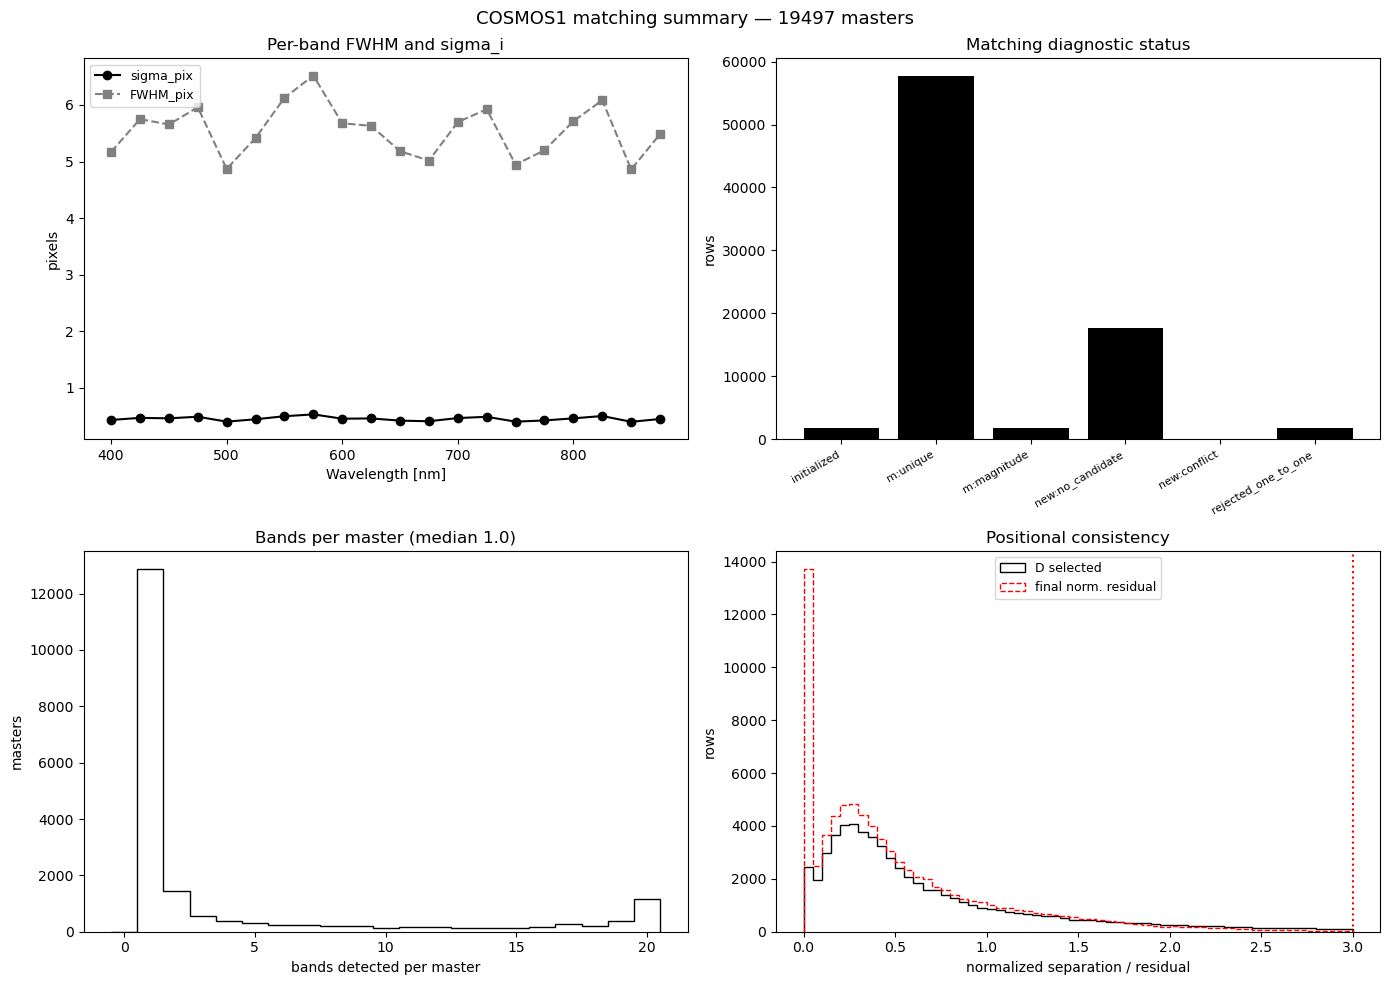

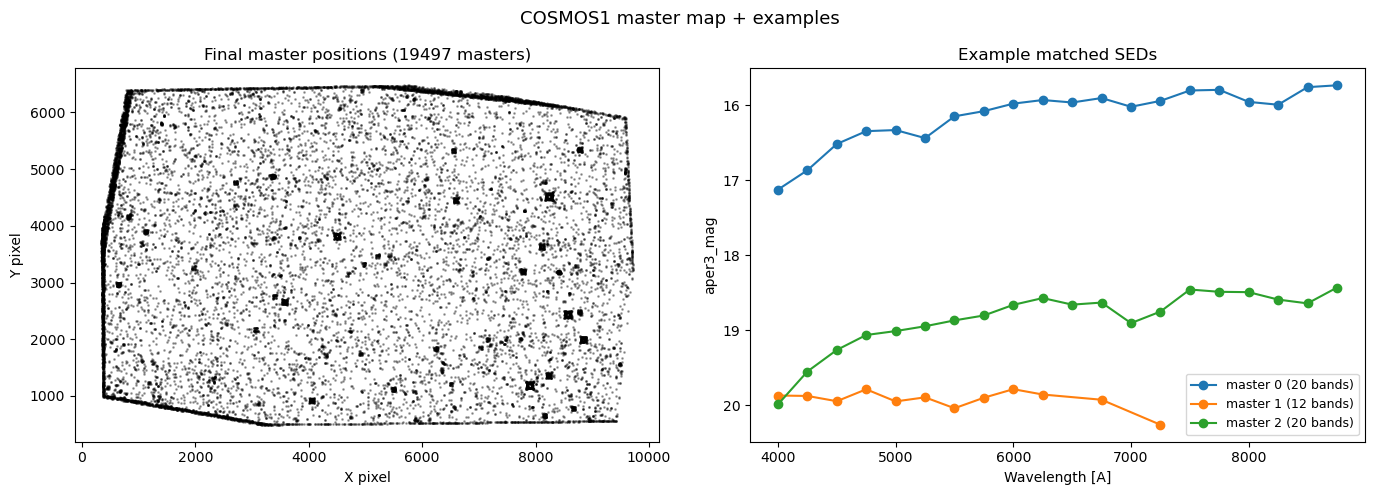

Saved figures to /Users/mac_seo/Research_local/7DTonCOSMOS/output/COSMOS1/singlebandphot/matching/figures


In [5]:
# 3.4b Graphical summary: uncertainties, status, completeness, separations, sky map, example SEDs
import numpy as np
import matplotlib.pyplot as plt

match_dir = PROJECT_ROOT / f"output/COSMOS{COSMOS}/singlebandphot/matching"
fig_dir = match_dir / 'figures'
fig_dir.mkdir(parents=True, exist_ok=True)

bands = list(band_uncertainty['band'])
x_wl = np.array([int(b[1:]) for b in bands])
sigma_pix = np.asarray(band_uncertainty['sigma_pix'], dtype=float)
fwhm_pix = np.asarray(band_uncertainty['fwhm_pix'], dtype=float)

statuses, counts = np.unique(np.asarray(matching_diagnostics['match_status']).astype(str), return_counts=True)
order = ['initialized', 'matched_unique', 'matched_magnitude', 'matched_position_fallback',
         'new_master_no_candidate', 'new_master_conflict', 'rejected_one_to_one']
statuses = [s for s in order if s in set(np.asarray(statuses).astype(str).tolist())]
counts = [int((np.asarray(matching_diagnostics['match_status']).astype(str) == s).sum()) for s in statuses]

# bands detected per master
n_bands = np.zeros(len(matching_table), dtype=int)
for b in BANDS_7DT:
    if b not in matching_table.colnames:
        continue
    col = matching_table[b]
    mask = np.ma.getmaskarray(col) if np.ma.isMaskedArray(col) else np.zeros(len(col), dtype=bool)
    n_bands += (~mask).astype(int)

sel = np.asarray(matching_diagnostics['selected']).astype(bool)
Dsel = np.asarray(matching_diagnostics['normalized_separation'], dtype=float)[sel]
Dsel = Dsel[np.isfinite(Dsel)]
nres = np.asarray(consistency_diagnostics['normalized_residual'], dtype=float)
nres = nres[np.isfinite(nres)]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
ax = axes[0, 0]
ax.plot(x_wl, sigma_pix, 'o-', color='black', label='sigma_pix')
ax.plot(x_wl, fwhm_pix, 's--', color='gray', label='FWHM_pix')
ax.set_xlabel('Wavelength [nm]')
ax.set_ylabel('pixels')
ax.set_title('Per-band FWHM and sigma_i')
ax.legend(fontsize=9)

ax = axes[0, 1]
ax.bar(range(len(statuses)), counts, color='black')
ax.set_xticks(range(len(statuses)))
ax.set_xticklabels([s.replace('matched_', 'm:').replace('new_master_', 'new:') for s in statuses], rotation=30, ha='right', fontsize=8)
ax.set_ylabel('rows')
ax.set_title('Matching diagnostic status')

ax = axes[1, 0]
ax.hist(n_bands, bins=np.arange(0, 22) - 0.5, histtype='step', color='black')
ax.set_xlabel('bands detected per master')
ax.set_ylabel('masters')
ax.set_title(f'Bands per master (median {float(np.median(n_bands)):.1f})')

ax = axes[1, 1]
ax.hist(Dsel, bins=60, range=(0, 3), histtype='step', color='black', label='D selected')
ax.hist(nres, bins=60, range=(0, 3), histtype='step', color='red', linestyle='--', label='final norm. residual')
ax.axvline(3, color='red', linestyle=':')
ax.set_xlabel('normalized separation / residual')
ax.set_ylabel('rows')
ax.set_title('Positional consistency')
ax.legend(fontsize=9)

fig.suptitle(f"COSMOS{COSMOS} matching summary — {len(matching_table)} masters", fontsize=13)
fig.tight_layout()
fig.savefig(fig_dir / 'matching_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# --- sky map of final master positions + example SEDs ---
mid_all = np.asarray(consistency_diagnostics['master_id'])
fx_all = np.asarray(consistency_diagnostics['final_master_x'], dtype=float)
fy_all = np.asarray(consistency_diagnostics['final_master_y'], dtype=float)
_, first_idx = np.unique(mid_all, return_index=True)
Fx, Fy = fx_all[first_idx], fy_all[first_idx]

# pick 3 well-measured masters (many bands, no suspect flag)
flag = np.asarray(consistency_diagnostics['consistency_flag']).astype(str)
sus_masters = set(mid_all[flag == 'suspect'].tolist())
cand = [i for i in range(len(matching_table)) if n_bands[i] >= 10 and i not in sus_masters][:3]

fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))
axes2[0].scatter(Fx, Fy, s=1, color='black', alpha=0.3)
axes2[0].set_xlabel('X pixel')
axes2[0].set_ylabel('Y pixel')
axes2[0].set_title(f'Final master positions ({len(Fx)} masters)')
axes2[0].set_aspect('equal', adjustable='box')

ax = axes2[1]
cat_cache = {}
try:
    _mc = matching_catalogs
except NameError:
    _mc = {}
for k, i in enumerate(cand):
    wl, mag = [], []
    for b in BANDS_7DT:
        col = matching_table[b]
        mask = np.ma.getmaskarray(col) if np.ma.isMaskedArray(col) else np.zeros(len(col), dtype=bool)
        if mask[i]:
            continue
        sid = int(col[i])
        if b not in _mc:
            try:
                _mc[b] = Table.read(
                    PROJECT_ROOT / f"output/COSMOS{COSMOS}/singlebandphot" / f"cat_cosmos{COSMOS}_{b}.fits"
                )
            except Exception:
                continue
        t = _mc[b]
        r = t[t['source_id'] == sid]
        if len(r) == 0:
            continue
        if not np.isfinite(float(r['aper3_mag'][0])):
            continue
        wl.append(int(b[1:]) * 10)
        mag.append(float(r['aper3_mag'][0]))
    ax.plot(wl, mag, 'o-', label=f"master {int(matching_table['master_id'][i])} ({len(wl)} bands)")
ax.set_xlabel('Wavelength [A]')
ax.set_ylabel('aper3_mag')
ax.invert_yaxis()
ax.set_title('Example matched SEDs')
ax.legend(fontsize=9)

fig2.suptitle(f"COSMOS{COSMOS} master map + examples", fontsize=13)
fig2.tight_layout()
fig2.savefig(fig_dir / 'matching_sky_sed.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved figures to {fig_dir}")


### 3.5 Master catalog of 20-full matched sources (FITS only)

Strict subset of `matching_table` with all 20 bands filled.
Positions are the inverse-variance weighted centroid expectation values
(`w_i = 1/sigma_band_i^2`, same weights as section 3.2); RA/Dec is that
pixel centroid transformed with the notebook `wcs` (origin=1, verified:
SE++ `PixelCentroid` is 1-based and origin=1 reproduces `world_centroid`
to machine precision). Photometry copies `aper3_mag` / `aper3_mag_err`
of the matched `source_id` per band into `mag_{band}` / `mag_err_{band}`.


In [11]:
# 3.5 Master catalog of 20-full matched sources (FITS only)
import numpy as np

match_dir = PROJECT_ROOT / f"output/COSMOS{COSMOS}/singlebandphot/matching"
if 'matching_table' not in dir():
    matching_table = Table.read(match_dir / 'matching_catalog.fits')
if 'consistency_diagnostics' not in dir():
    consistency_diagnostics = Table.read(match_dir / 'consistency_diagnostics.fits')
if 'band_sigma' not in dir():
    _bu = Table.read(match_dir / 'band_uncertainty.fits')
    band_sigma = {r['band']: float(r['sigma_pix']) for r in _bu}
try:
    _ms = master_states
except NameError:
    _ms = None
try:
    _mc = matching_catalogs
except NameError:
    _mc = {}

bands20 = [b for b in BANDS_7DT if b in matching_table.colnames]
assert len(bands20) == 20, f"expected 20 band columns, got {bands20}"

# --- select strict 20-full rows ---
n_bands_full = np.zeros(len(matching_table), dtype=int)
for b in bands20:
    col = matching_table[b]
    mask = np.ma.getmaskarray(col) if np.ma.isMaskedArray(col) else np.zeros(len(col), dtype=bool)
    n_bands_full += (~mask).astype(int)
full20_idx = np.where(n_bands_full == 20)[0]
print(f"20-full masters: {len(full20_idx)} / {len(matching_table)}")

# --- final weighted centroid per master (expectation value) ---
final_xy = {}  # master_id -> (x, y)
if _ms is not None:
    for m in _ms:
        sw = 0.0; swx = 0.0; swy = 0.0
        for mem in m['members']:
            w = 1.0 / (float(mem['sigma_band']) ** 2)
            sw += w; swx += w * mem['x']; swy += w * mem['y']
        final_xy[int(m['master_id'])] = (swx / sw, swy / sw)
else:
    _mid = np.asarray(consistency_diagnostics['master_id'])
    _fx = np.asarray(consistency_diagnostics['final_master_x'], dtype=float)
    _fy = np.asarray(consistency_diagnostics['final_master_y'], dtype=float)
    _, _fi = np.unique(_mid, return_index=True)
    for mid, ix in zip(_mid[_fi].tolist(), _fi.tolist()):
        final_xy[int(mid)] = (float(_fx[ix]), float(_fy[ix]))

# cross-check against saved consistency finals
_mid = np.asarray(consistency_diagnostics['master_id'])
_fx = np.asarray(consistency_diagnostics['final_master_x'], dtype=float)
_fy = np.asarray(consistency_diagnostics['final_master_y'], dtype=float)
_, _fi = np.unique(_mid, return_index=True)
cons_xy = {int(m): (float(x), float(y)) for m, x, y in zip(_mid[_fi], _fx[_fi], _fy[_fi])}
max_dev = max(
    float(np.hypot(final_xy[int(matching_table['master_id'][i])][0] - cons_xy[int(matching_table['master_id'][i])][0],
                   final_xy[int(matching_table['master_id'][i])][1] - cons_xy[int(matching_table['master_id'][i])][1]))
    for i in full20_idx
)
print(f"max centroid cross-check residual vs consistency finals: {max_dev:.2e} pix")
assert max_dev < 1e-6, "weighted-centroid definition drifted from section 3.2/3.3"

# --- RA/Dec from the expectation pixel centroid (origin=1 verified for SE++ centroids) ---
mids = [int(matching_table['master_id'][i]) for i in full20_idx]
px = np.array([final_xy[m][0] for m in mids], dtype=float)
py = np.array([final_xy[m][1] for m in mids], dtype=float)
ra, dec = wcs.all_pix2world(px, py, 1)
ra = np.asarray(ra, dtype=float); dec = np.asarray(dec, dtype=float)
assert bool(np.isfinite(ra).all() and np.isfinite(dec).all()), "non-finite RA/Dec produced"

# --- photometry lookup: matched source_id -> aper3_mag / aper3_mag_err ---
mag_cols = {b: np.full(len(full20_idx), np.nan) for b in bands20}
magerr_cols = {b: np.full(len(full20_idx), np.nan) for b in bands20}
cat_cache = dict(_mc)
for b in bands20:
    if b not in cat_cache:
        cat_cache[b] = Table.read(
            PROJECT_ROOT / f"output/COSMOS{COSMOS}/singlebandphot" / f"cat_cosmos{COSMOS}_{b}.fits"
        )
for k, i in enumerate(full20_idx):
    for b in bands20:
        sid = int(matching_table[b][i])
        t = cat_cache[b]
        r = t[np.asarray(t['source_id']) == sid]
        assert len(r) == 1, f"master {mids[k]} band {b}: {len(r)} rows for source_id {sid}"
        mval, meval = float(r['aper3_mag'][0]), float(r['aper3_mag_err'][0])
        assert np.isfinite(mval) and np.isfinite(meval), f"master {mids[k]} band {b}: non-finite mag"
        mag_cols[b][k] = mval
        magerr_cols[b][k] = meval

master_full20 = Table()
master_full20['master_id'] = np.array(mids, dtype=np.int64)
master_full20['pixel_centroid_x'] = px
master_full20['pixel_centroid_y'] = py
master_full20['ra'] = ra
master_full20['dec'] = dec
for b in bands20:
    master_full20[f"mag_{b}"] = mag_cols[b]
for b in bands20:
    master_full20[f"mag_err_{b}"] = magerr_cols[b]

master_full20_path = match_dir / 'master_full20_catalog.fits'
master_full20.write(master_full20_path, overwrite=True)
print(f"rows: {len(master_full20)}, columns: {len(master_full20.colnames)}")
print(f"Saved FITS to {master_full20_path}")
master_full20[:5].pprint(max_width=-1)


20-full masters: 1157 / 19497
max centroid cross-check residual vs consistency finals: 0.00e+00 pix


rows: 1157, columns: 45
Saved FITS to /Users/mac_seo/Research_local/7DTonCOSMOS/output/COSMOS1/singlebandphot/matching/master_full20_catalog.fits
master_id  pixel_centroid_x  pixel_centroid_y          ra                dec              mag_m400           mag_m425           mag_m450           mag_m475           mag_m500           mag_m525           mag_m550           mag_m575           mag_m600           mag_m625           mag_m650           mag_m675           mag_m700           mag_m725           mag_m750           mag_m775           mag_m800           mag_m825           mag_m850           mag_m875          mag_err_m400          mag_err_m425          mag_err_m450          mag_err_m475          mag_err_m500          mag_err_m525          mag_err_m550          mag_err_m575         mag_err_m600          mag_err_m625          mag_err_m650          mag_err_m675          mag_err_m700          mag_err_m725          mag_err_m750          mag_err_m775          mag_err_m800         mag_err_m825 

### 3.8 Combined cutouts + SED (single figure)

One call draws the §3.6 global-stretch 20-band cutouts (top, 4×5) and the
§3.7 SED (bottom, full width) for the same master. Same data sources and
conventions as the two separate plots.


['master_id', 'pixel_centroid_x', 'pixel_centroid_y', 'ra', 'dec', 'mag_m400', 'mag_m425', 'mag_m450', 'mag_m475', 'mag_m500', 'mag_m525', 'mag_m550', 'mag_m575', 'mag_m600', 'mag_m625', 'mag_m650', 'mag_m675', 'mag_m700', 'mag_m725', 'mag_m750', 'mag_m775', 'mag_m800', 'mag_m825', 'mag_m850', 'mag_m875', 'mag_err_m400', 'mag_err_m425', 'mag_err_m450', 'mag_err_m475', 'mag_err_m500', 'mag_err_m525', 'mag_err_m550', 'mag_err_m575', 'mag_err_m600', 'mag_err_m625', 'mag_err_m650', 'mag_err_m675', 'mag_err_m700', 'mag_err_m725', 'mag_err_m750', 'mag_err_m775', 'mag_err_m800', 'mag_err_m825', 'mag_err_m850', 'mag_err_m875']
Saved image to /Users/mac_seo/Research_local/7DTonCOSMOS/output/COSMOS1/singlebandphot/matching/figures/master_full20_on_detection_image.png
tile 00 r0c0 x:[0,2040) y:[0,1700) n=38 -> /Users/mac_seo/Research_local/7DTonCOSMOS/output/COSMOS1/singlebandphot/matching/figures/master_full20_tiles/master_full20_tile_00_r0c0.png
tile 01 r0c1 x:[2040,4080) y:[0,1700) n=57 -> /Us

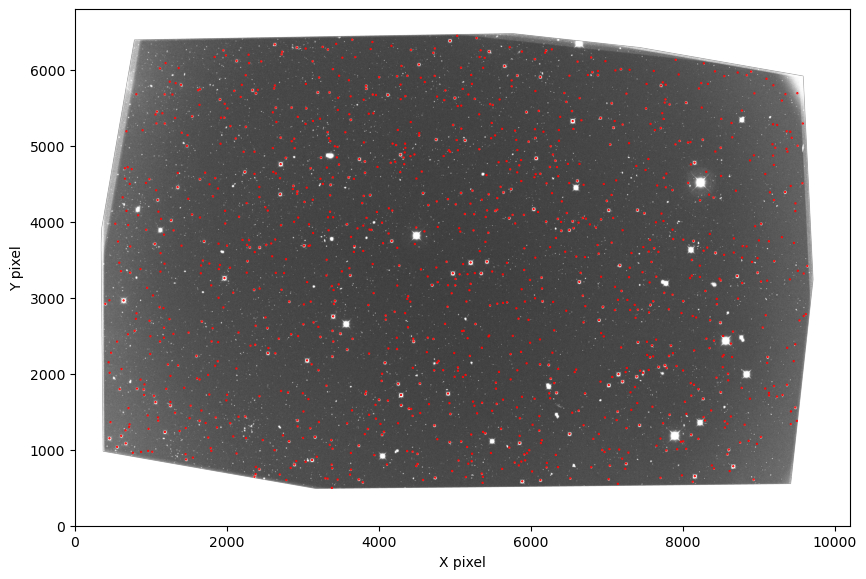

In [19]:
from tqdm.auto import tqdm
# 3.8 Combined 20-band cutouts + SED in one figure
def plot_MasterCatalogSourceSED(COSMOS, master_id=None, length=10, vmin=None, vmax=None,
                                save_path=None):
    """Cutouts (global stretch) + SED for one 20-full master in a single figure.

    Same conventions as plot_MasterCatalogSource / plot_MasterCatalogSED.
    master_id=None plots a random full20 source (and prints the chosen id).
    save_path: optional PNG path; when given, the figure is saved
    (parent dirs created) before plt.show().
    """
    match_dir = PROJECT_ROOT / f"output/COSMOS{COSMOS}/singlebandphot/matching"
    try:
        _mfull = master_full20
    except NameError:
        _mfull = Table.read(match_dir / 'master_full20_catalog.fits')
    try:
        _mtable = matching_table
    except NameError:
        _mtable = Table.read(match_dir / 'matching_catalog.fits')

    if master_id is None:
        idx = random.randrange(len(_mfull))
        master_id = int(_mfull['master_id'][idx])
        print(f"random master_id: {master_id}")
    else:
        hit = np.where(np.asarray(_mfull['master_id']) == int(master_id))[0]
        if len(hit) == 0:
            raise ValueError(f'{master_id} not found in master_full20')
        idx = int(hit[0])
    row = _mfull[idx]
    mt_hit = np.where(np.asarray(_mtable['master_id']) == int(master_id))[0]
    if len(mt_hit) == 0:
        raise ValueError(f'{master_id} not found in matching_table')
    mt_row = _mtable[int(mt_hit[0])]

    # --- COSMOS_FINALCAT pixel positions (cached, 0-based to match cutout extent) ---
    try:
        _fx_all = _COSMOS_FINALCAT_X
        _fy_all = _COSMOS_FINALCAT_Y
    except NameError:
        _finalcat_path = PROJECT_ROOT / 'COSMOS_data/COSMOS_finalcat.fits'
        _finalcat = Table.read(_finalcat_path, hdu=1)
        try:
            _wcs_fc = wcs
        except NameError:
            _wcs_fc = WCS(fits.getheader(image_paths.get(BANDS_7DT[0]) or get_image_path(COSMOS, BANDS_7DT[0])))
        _fx_all, _fy_all = _wcs_fc.world_to_pixel_values(np.asarray(_finalcat['RA'], dtype=float), np.asarray(_finalcat['DEC'], dtype=float))
        _fx_all = np.asarray(_fx_all, dtype=float)
        _fy_all = np.asarray(_fy_all, dtype=float)
        _COSMOS_FINALCAT_X, _COSMOS_FINALCAT_Y = _fx_all, _fy_all

    cx = float(row['pixel_centroid_x'])
    cy = float(row['pixel_centroid_y'])
    half = float(length) / 2

    cutouts, metas = [], []
    for band in BANDS_7DT:
        path = image_paths.get(band, None) if 'image_paths' in dir() else None
        if path is None:
            path = get_image_path(COSMOS, band)
        if path is None:
            cutouts.append(None)
            metas.append((band, None, float('nan')))
            continue
        image = fits.getdata(path)
        ny, nx = image.shape[0], image.shape[1]
        if not (0 <= int(np.rint(cx)) < nx and 0 <= int(np.rint(cy)) < ny):
            raise ValueError(
                f'Master centroid is outside the {band} image: '
                f'x={cx}, y={cy}'
            )
        xmin = max(0, int(cx - half))
        xmax = min(nx, int(cx + half))
        ymin = max(0, int(cy - half))
        ymax = min(ny, int(cy + half))
        cutouts.append((
            np.asarray(image[ymin:ymax, xmin:xmax], dtype=float),
            xmin, xmax, ymin, ymax,
        ))
        metas.append((band, int(mt_row[band]), float(row[f'mag_{band}'])))

    # --- one shared interval from the stacked cutouts (same as 3.6) ---
    if vmin is None or vmax is None:
        stack = np.concatenate(
            [c[np.isfinite(c)] for c, *_ in cutouts if c is not None and np.isfinite(c).any()]
        )
        auto_vmin, auto_vmax = np.nanpercentile(stack, [5, 95])
        if vmin is None:
            vmin = float(auto_vmin)
        if vmax is None:
            vmax = float(auto_vmax)
        if not vmax > vmin:
            vmax = vmin + 1.0
    norm = ImageNormalize(vmin=float(vmin), vmax=float(vmax))

    # --- SED vectors (same as 3.7) ---
    sed_x = np.array([int(b[1:]) * 10 for b in BANDS_7DT], dtype=float)
    sed_y = np.array([float(row[f'mag_{b}']) for b in BANDS_7DT], dtype=float)
    sed_yerr = np.array([float(row[f'mag_err_{b}']) for b in BANDS_7DT], dtype=float)
    sed_good = np.isfinite(sed_y) & np.isfinite(sed_yerr) & (sed_y != 0)

    fig = plt.figure(figsize=(20, 22))
    gs = fig.add_gridspec(5, 5, hspace=0.45, wspace=0.35)
    for k, (cut_info, (band, sid, mag)) in enumerate(zip(cutouts, metas)):
        ax = fig.add_subplot(gs[k // 5, k % 5])
        if cut_info is None:
            ax.text(0.5, 0.5, f'{band}\nno image', ha='center', va='center')
            ax.set_title(band)
            continue
        cut, xmin, xmax, ymin, ymax = cut_info
        ax.imshow(
            cut, cmap='gray', norm=norm, origin='lower',
            extent=[xmin, xmax, ymin, ymax],
        )
        ax.axhline(y=cy, color='cyan', linestyle='--', linewidth=0.8, alpha=0.7)
        ax.axvline(x=cx, color='cyan', linestyle='--', linewidth=0.8, alpha=0.7)
        _sel_fc = (_fx_all >= xmin) & (_fx_all < xmax) & (_fy_all >= ymin) & (_fy_all < ymax)
        if np.any(_sel_fc):
            ax.plot(_fx_all[_sel_fc], _fy_all[_sel_fc], marker='x', linestyle='None', markersize=8, markeredgewidth=1.2, color='blue', alpha=0.3, label='COSMOS_FINALCAT' if k == 0 else None)
        if k == 0:
            _h, _l = ax.get_legend_handles_labels()
            if _h:
                ax.legend(fontsize=7, loc='upper right')
        ax.set_title(f"{band} #{sid} · {mag:.2f}", fontsize=9)
        ax.set_xlabel('X pixel')
        ax.set_ylabel('Y pixel')

    ax_sed = fig.add_subplot(gs[4, :])
    if not sed_good.any():
        ax_sed.text(0.5, 0.5, 'no finite mag values', ha='center', va='center')
    else:
        ax_sed.errorbar(sed_x[sed_good], sed_y[sed_good], yerr=sed_yerr[sed_good],
                        fmt='o', capsize=3)
    ax_sed.set_xlabel('Wavelength [A]')
    ax_sed.set_ylabel('Magnitude')
    ax_sed.invert_yaxis()
    ax_sed.set_title(f"SED — master {int(master_id)}", fontsize=11)

    fig.suptitle(
        f"COSMOS{COSMOS} master {int(master_id)} — "
        f"x={cx:.2f} y={cy:.2f} ra={float(row['ra']):.6f} dec={float(row['dec']):.6f} "
        f"(global stretch vmin={float(vmin):.2f} vmax={float(vmax):.2f})",
        fontsize=13,
    )
    fig.tight_layout()
    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Saved combined figure to {save_path}')
    else:
        plt.show()

match_dir = PROJECT_ROOT / f"output/COSMOS{COSMOS}/singlebandphot/matching"
fig_dir = match_dir / 'figures'
master_full20 = Table.read(match_dir / 'master_full20_catalog.fits')

detection_image_path = Path('/Users/mac_seo/Research_local/7DTonCOSMOS/COSMOS_data/COSMOS1/COSMOS1_detectionimage.fits')
detection_image = fits.getdata(detection_image_path)
print(master_full20.colnames)

# Full-frame overview (kept)
plot_ImageAndDetectedSources(detection_image, master_full20, save_path=fig_dir / f'master_full20_on_detection_image.png')

# --- Divide detection image into 20 regions (4 rows x 5 cols, no overlap) ---
# Rectangular tiles covering the full image; each tile saved separately.
n_rows, n_cols = 4, 5
SHOW_IDS = True  # set True to label master_id on tiles (only readable when zoomed)
ny, nx = detection_image.shape
y_edges = np.linspace(0, ny, n_rows + 1).astype(int)
x_edges = np.linspace(0, nx, n_cols + 1).astype(int)

x_all = np.asarray(master_full20['pixel_centroid_x'], dtype=float)
y_all = np.asarray(master_full20['pixel_centroid_y'], dtype=float)
if 'master_id' in master_full20.colnames:
    id_all = np.asarray(master_full20['master_id'])
else:
    id_all = np.asarray(master_full20['source_id'])

tile_dir = fig_dir / 'master_full20_tiles'
tile_dir.mkdir(parents=True, exist_ok=True)

for iy in range(n_rows):
    for ix in range(n_cols):
        tile_id = iy * n_cols + ix
        xmin, xmax = int(x_edges[ix]), int(x_edges[ix + 1])
        ymin, ymax = int(y_edges[iy]), int(y_edges[iy + 1])
        cx, cy = (xmin + xmax) / 2, (ymin + ymax) / 2

        sel = (xmin <= x_all) & (x_all < xmax) & (ymin <= y_all) & (y_all < ymax)
        tx, ty, tid = x_all[sel], y_all[sel], id_all[sel]

        image_plot = detection_image[ymin:ymax, xmin:xmax]
        norm = ImageNormalize(image_plot, interval=ZScaleInterval())

        # keep aspect roughly true on screen
        aspect = (ymax - ymin) / max(1, (xmax - xmin))
        fig, ax = plt.subplots(figsize=(10, 10 * aspect))

        ax.imshow(image_plot, cmap='gray', norm=norm, origin='lower',
                  extent=[xmin, xmax, ymin, ymax])

        radius_pix = 5.94
        for x, y, sid in zip(tx, ty, tid):
            ax.add_patch(Circle((x, y), radius=radius_pix, fill=False,
                                edgecolor='red', linewidth=1))
            if SHOW_IDS:
                ax.text(x + radius_pix, y + radius_pix, str(sid),
                        color='yellow', fontsize=7, ha='left', va='bottom',
                        bbox=dict(facecolor='black', alpha=0.5, edgecolor='none', pad=1))

        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        ax.set_xlabel('X pixel')
        ax.set_ylabel('Y pixel')
        ax.set_title(f"master_full20 tile {tile_id:02d} (row {iy}, col {ix}) "
                     f"x:[{xmin},{xmax}) y:[{ymin},{ymax}) n={int(sel.sum())}",
                     fontsize=11)

        save_path = tile_dir / f'master_full20_tile_{tile_id:02d}_r{iy}c{ix}.png'
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.close(fig)
        print(f"tile {tile_id:02d} r{iy}c{ix} x:[{xmin},{xmax}) y:[{ymin},{ymax}) "
              f"n={int(sel.sum())} -> {save_path}")
